In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels import PanelOLS

MONTH_MAP = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}


def prepare_panel(df, ols=False):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()
    df['brand_model'] = df['brand'].str.strip() + ' | ' + df['model'].str.strip()
    df['month'] = df['month'].astype(str).str.lower().str.strip()
    df['month_num'] = df['month'].map(MONTH_MAP)
    df['year_month'] = pd.to_datetime(
        df['year'].astype(str) + '-' + df['month_num'].astype(str) + '-01'
    )
    df['sum'] = pd.to_numeric(df['sum'], errors='coerce').fillna(0)
    df['cc'] = pd.to_numeric(df['cc'], errors='coerce')
    df['fuel'] = df['fuel'].astype(str).str.strip()
    df['panel_id'] = (
        df['brand_model'] + ' | ' + df['fuel'] + ' | ' + df['cc'].fillna(-1).astype(int).astype(str)
    )
    if ols:
        g = df.groupby(['panel_id', 'year_month'], as_index=False).agg(
            sum=('sum', 'sum'),
            diesel_dummy=('diesel_dummy', 'first'),
            post=('post', 'first'),
            year=('year', 'first'),
        )
        g['diesel_post'] = g['diesel_dummy'] * g['post']
        g['log_sum'] = np.log(g['sum'] + 1)
        return g
    g = df.groupby(['panel_id', 'year_month'], as_index=False).agg(
        sum=('sum', 'sum'),
        treated=('treated', 'first'),
        post=('post', 'first'),
        year=('year', 'first'),
    )
    g['log_sum'] = np.log(g['sum'] + 1)
    return g


def prepare_panel_2013(df):
    g = prepare_panel(df, ols=False)
    g['treat_post'] = g['treated'] * g['post']
    return g

### Политика 2018

In [2]:
df_ols = pd.read_excel('dataset_ols_2018.xlsx', sheet_name='Sheet1')
df_ols = prepare_panel(df_ols, ols=True)
df_ols_panel = df_ols.set_index(['panel_id', 'year_month'])
mod_ols = PanelOLS(
    df_ols_panel['log_sum'],
    df_ols_panel[['diesel_post']],
    entity_effects=True,
    time_effects=True,
)
res_ols = mod_ols.fit(cov_type='clustered', cluster_entity=True)
print(res_ols.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                log_sum   R-squared:                        0.0054
Estimator:                   PanelOLS   R-squared (Between):             -0.0535
No. Observations:               36300   R-squared (Within):               0.0251
Date:                Wed, May 06 2026   R-squared (Overall):             -0.0202
Time:                        15:06:18   Log-likelihood                -4.743e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      193.87
Entities:                         275   P-value                           0.0000
Avg Obs:                       132.00   Distribution:                 F(1,35893)
Min Obs:                       132.00                                           
Max Obs:                       132.00   F-statistic (robust):             5.3721
                            

In [3]:
c = res_ols.params['diesel_post']
s = res_ols.std_errors['diesel_post']
p = res_ols.pvalues['diesel_post']
lo = res_ols.conf_int().loc['diesel_post', 'lower']
hi = res_ols.conf_int().loc['diesel_post', 'upper']
print(c, s, p, lo, hi, int(res_ols.nobs), res_ols.rsquared_within)

-0.28546218304299115 0.12316190711581461 0.020466884116272288 -0.5268632256504845 -0.0440611404354978 36300 0.025078510246942187


In [4]:
df_es = pd.read_csv('dataset_eventstudy_2018.csv')
df_es = prepare_panel(df_es, ols=False)
BASE_YEAR = 2017
years = sorted(df_es['year'].unique())
treat_cols = []
for yr in years:
    if yr == BASE_YEAR:
        continue
    col = f'treat_{yr}'
    df_es[col] = (df_es['treated'] * (df_es['year'] == yr)).astype(int)
    treat_cols.append(col)
df_es_panel = df_es.set_index(['panel_id', 'year_month'])
mod_es = PanelOLS(
    df_es_panel['log_sum'],
    df_es_panel[treat_cols],
    entity_effects=True,
    time_effects=True,
)
res_es = mod_es.fit(cov_type='clustered', cluster_entity=True)
print(res_es.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                log_sum   R-squared:                        0.0036
Estimator:                   PanelOLS   R-squared (Between):             -0.0473
No. Observations:               23100   R-squared (Within):               0.0115
Date:                Wed, May 06 2026   R-squared (Overall):             -0.0278
Time:                        15:06:20   Log-likelihood                -2.511e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      13.608
Entities:                         275   P-value                           0.0000
Avg Obs:                       84.000   Distribution:                 F(6,22736)
Min Obs:                       84.000                                           
Max Obs:                       84.000   F-statistic (robust):             2.6824
                            

In [5]:
rows = [{'year': BASE_YEAR, 'event_time': 0, 'coef': 0.0, 'ci_lo': 0.0, 'ci_hi': 0.0}]
ci = res_es.conf_int()
for yr in years:
    if yr == BASE_YEAR:
        continue
    col = f'treat_{yr}'
    rows.append({
        'year': yr,
        'event_time': yr - BASE_YEAR,
        'coef': res_es.params[col],
        'ci_lo': ci.loc[col, 'lower'],
        'ci_hi': ci.loc[col, 'upper'],
    })
es = pd.DataFrame(rows).sort_values('event_time').reset_index(drop=True)
print(es.to_string(index=False))

 year  event_time      coef     ci_lo    ci_hi
 2016          -1 -0.121813 -0.295653 0.052028
 2017           0  0.000000  0.000000 0.000000
 2018           1 -0.198198 -0.459026 0.062630
 2019           2 -0.162462 -0.357584 0.032660
 2020           3 -0.222057 -0.449017 0.004902
 2021           4 -0.081394 -0.364639 0.201852
 2022           5 -0.308871 -0.646604 0.028863


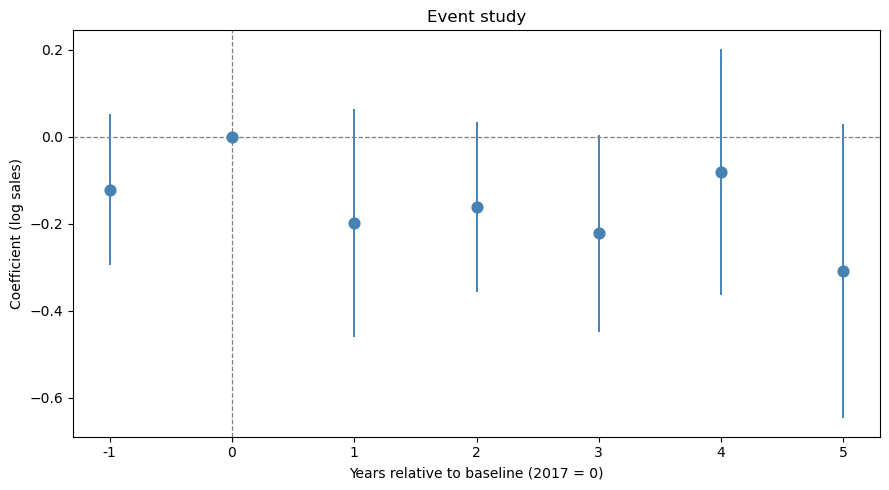

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.vlines(es['event_time'], es['ci_lo'], es['ci_hi'], linewidth=1.4, color='steelblue')
ax.scatter(es['event_time'], es['coef'], s=60, color='steelblue', zorder=5)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.9)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.9)
ax.set_xlabel('Years relative to baseline (2017 = 0)')
ax.set_ylabel('Coefficient (log sales)')
ax.set_title('Event study')
ax.set_xticks(es['event_time'])
ax.set_xticklabels(es['event_time'].astype(str))
plt.tight_layout()
plt.savefig('event_study_2018_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

### Политика 2013

In [7]:
df_2013 = pd.read_excel('dataset_ols_and_eventstudy_2013.xlsx', sheet_name='Sheet1')
df_2013 = prepare_panel_2013(df_2013)
df_2013_panel = df_2013.set_index(['panel_id', 'year_month'])
mod_ols_2013 = PanelOLS(
    df_2013_panel['log_sum'],
    df_2013_panel[['treat_post']],
    entity_effects=True,
    time_effects=True,
)
res_ols_2013 = mod_ols_2013.fit(cov_type='clustered', cluster_entity=True)
print(res_ols_2013.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                log_sum   R-squared:                        0.0108
Estimator:                   PanelOLS   R-squared (Between):              0.1001
No. Observations:                 720   R-squared (Within):               0.0340
Date:                Wed, May 06 2026   R-squared (Overall):              0.0777
Time:                        15:06:20   Log-likelihood                   -1487.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.9957
Entities:                          10   P-value                           0.0084
Avg Obs:                       72.000   Distribution:                   F(1,638)
Min Obs:                       72.000                                           
Max Obs:                       72.000   F-statistic (robust):             0.2976
                            

In [8]:
df_es13 = prepare_panel(pd.read_excel('dataset_ols_and_eventstudy_2013.xlsx', sheet_name='Sheet1'), ols=False)
BASE_YEAR_2013 = 2012
years13 = sorted(df_es13['year'].unique())
treat_cols13 = []
for yr in years13:
    if yr == BASE_YEAR_2013:
        continue
    col = f'treat_{yr}'
    df_es13[col] = (df_es13['treated'] * (df_es13['year'] == yr)).astype(int)
    treat_cols13.append(col)
df_es13_panel = df_es13.set_index(['panel_id', 'year_month'])
mod_es13 = PanelOLS(
    df_es13_panel['log_sum'],
    df_es13_panel[treat_cols13],
    entity_effects=True,
    time_effects=True,
)
res_es13 = mod_es13.fit(cov_type='clustered', cluster_entity=True)
print(res_es13.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                log_sum   R-squared:                        0.0141
Estimator:                   PanelOLS   R-squared (Between):              0.1221
No. Observations:                 720   R-squared (Within):               0.0436
Date:                Wed, May 06 2026   R-squared (Overall):              0.0955
Time:                        15:06:21   Log-likelihood                   -1486.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.8187
Entities:                          10   P-value                           0.1071
Avg Obs:                       72.000   Distribution:                   F(5,634)
Min Obs:                       72.000                                           
Max Obs:                       72.000   F-statistic (robust):             2.4503
                            

In [9]:
rows13 = [{'year': BASE_YEAR_2013, 'event_time': 0, 'coef': 0.0, 'ci_lo': 0.0, 'ci_hi': 0.0}]
ci13 = res_es13.conf_int()
for yr in years13:
    if yr == BASE_YEAR_2013:
        continue
    col = f'treat_{yr}'
    rows13.append({
        'year': yr,
        'event_time': yr - BASE_YEAR_2013,
        'coef': res_es13.params[col],
        'ci_lo': ci13.loc[col, 'lower'],
        'ci_hi': ci13.loc[col, 'upper'],
    })
es13 = pd.DataFrame(rows13).sort_values('event_time').reset_index(drop=True)
print(es13.to_string(index=False))

 year  event_time      coef     ci_lo    ci_hi
 2010          -2 -0.121958 -3.077474 2.833558
 2011          -1  0.415160 -3.714719 4.545040
 2012           0  0.000000  0.000000 0.000000
 2013           1  0.747876 -0.142807 1.638559
 2014           2  1.194892 -2.283139 4.672922
 2015           3  0.749499 -3.004259 4.503258


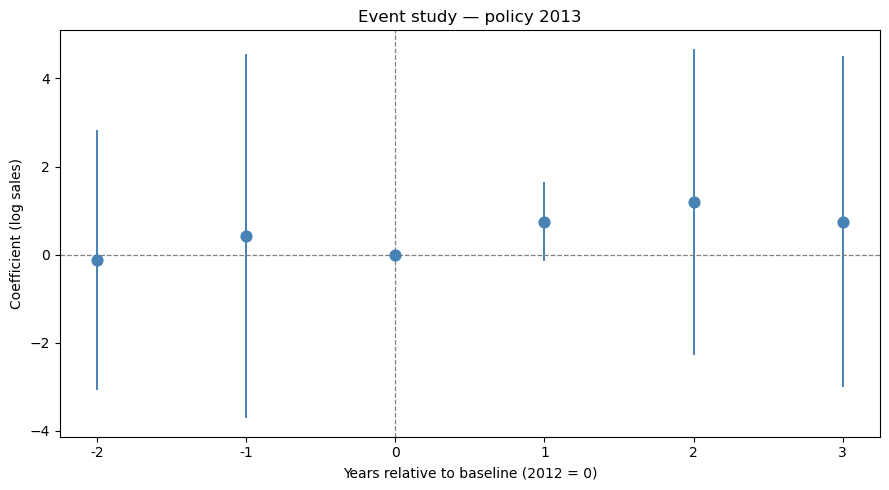

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.vlines(es13['event_time'], es13['ci_lo'], es13['ci_hi'], linewidth=1.4, color='steelblue')
ax.scatter(es13['event_time'], es13['coef'], s=60, color='steelblue', zorder=5)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.9)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.9)
ax.set_xlabel('Years relative to baseline (2012 = 0)')
ax.set_ylabel('Coefficient (log sales)')
ax.set_title('Event study — policy 2013')
ax.set_xticks(es13['event_time'])
ax.set_xticklabels(es13['event_time'].astype(str))
plt.tight_layout()
plt.savefig('event_study_2013_corrected.png', dpi=150, bbox_inches='tight')
plt.show()